#### Fig 2c "FB niches"

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 500)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [2]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [3]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266,0.010062,0.009213,0.056085,0.024774,0.080588,0.040189,0.030853,0.005049,0.038562,0.017642,0.068411,0.598156,0.124178,0.036192,0.026985,0.061592,0.055564,0.479931,0.034395,0.011473,0.129968,0.007446,

In [4]:
niches = ['Alv. FB/immune',  'Perib. FB', 'Adv. FB']

In [5]:
df = adata_vis[(adata_vis.obs['cond']!="UNC") &     (adata_vis.obs['factor_assigned'].isin(niches))].obs[['library_id','cond', 'factor_assigned']]

In [6]:
df

,library_id,cond,factor_assigned
AACATATTCTTGCGAA-1-18_57617_A1,18_57617_A1,IPF,Alv. FB/immune
AACATCTTAAGGCTCA-1-18_57617_A1,18_57617_A1,IPF,Perib. FB
AACCAAGGTATCAGGC-1-18_57617_A1,18_57617_A1,IPF,Adv. FB
AACCACTAACATGATT-1-18_57617_A1,18_57617_A1,IPF,Alv. FB/immune
AACCTACAGAGGTAGT-1-18_57617_A1,18_57617_A1,IPF,Alv. FB/immune
...,...,...,...
TGTCAGAAGTTGTAAC-1-22_16220_B1,22_16220_B1,IPF,Alv. FB/immune
TGTCCTCAACGTTCTA-1-22_16220_B1,22_16220_B1,IPF,Perib. FB
TGTCGAGTGCGTTAGC-1-22_16220_B1,22_16220_B1,IPF,Alv. FB/immune
TGTCGCGGAAGAGCTA-1-22_16220_B1,22_16220_B1,IPF,Alv. FB/immune


In [7]:
df['factor_assigned'].isna().sum()

np.int64(0)

In [8]:
print("NaNs in cond:", df['cond'].isna().sum())
print("NaNs in library_id:", df['library_id'].isna().sum())

NaNs in cond: 0
NaNs in library_id: 0


In [9]:
counts = df.groupby(['cond', 'library_id', 'factor_assigned']).size().reset_index(name='count')
print(counts.head())
print(counts.isna().sum())

  cond   library_id factor_assigned  count
0  CHP  06_30914_A1       Perib. FB      0
1  CHP  06_30914_A1  Alv. FB/immune      0
2  CHP  06_30914_A1         Adv. FB      0
3  CHP  08_38774_B2       Perib. FB      6
4  CHP  08_38774_B2  Alv. FB/immune   1385
cond               0
library_id         0
factor_assigned    0
count              0
dtype: int64


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_19374/3274666945.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['cond', 'library_id', 'factor_assigned']).size().reset_index(name='count')


In [10]:
# Step 1: Compute counts and proportions
counts = df.groupby(['cond', 'factor_assigned']).size().reset_index(name='count') # .reset_index() makes a dataframe
#counts = counts[counts['count'] > 0].copy()
total_counts = counts.groupby(['cond'])['count'].transform('sum') # .transform('sum') returns grouped sum the same number of times as the number of rows 
counts['proportion'] = counts['count'] / total_counts

# Step 2: Pivot to get proportions stacked per library_id
pivot_df = counts.pivot_table(
    index='cond',
    columns='factor_assigned',
    values='proportion',
    fill_value=0
)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_19374/1853875966.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(['cond', 'factor_assigned']).size().reset_index(name='count') # .reset_index() makes a dataframe
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_19374/1853875966.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = counts.groupby(['cond'])['count'].transform('sum') # .transform('sum') returns grouped sum the same number of times as the number of rows
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_19374/1853875966.py:8: FutureWa

In [11]:
counts

,cond,factor_assigned,count,proportion
0,CHP,Perib. FB,365,0.054002
1,CHP,Alv. FB/immune,5612,0.830300
2,CHP,Adv. FB,782,0.115698
3,IPF,Perib. FB,1406,0.105476
4,IPF,Alv. FB/immune,10078,0.756039
5,IPF,Adv. FB,1846,0.138485
6,NSIP,Perib. FB,1116,0.166791
7,NSIP,Alv. FB/immune,4144,0.619339
8,NSIP,Adv. FB,1431,0.213869


In [12]:
pivot_df

factor_assigned,Perib. FB,Alv. FB/immune,Adv. FB
cond,,,
CHP,0.054002,0.830300,0.115698
IPF,0.105476,0.756039,0.138485
NSIP,0.166791,0.619339,0.213869


In [13]:
pivot_df[pivot_df.mean().sort_values(ascending=False).index]

factor_assigned,Alv. FB/immune,Adv. FB,Perib. FB
cond,,,
CHP,0.830300,0.115698,0.054002
IPF,0.756039,0.138485,0.105476
NSIP,0.619339,0.213869,0.166791


In [14]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [15]:
paired_shuffled = ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

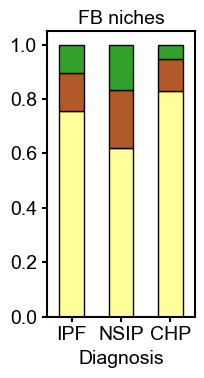

In [19]:

# Sort rows (condition) and columns
pivot_df = pivot_df[pivot_df.mean().sort_values(ascending=False).index].loc[["IPF",'NSIP','CHP'],:]

# Step 2: Plot stacked barplot
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(2.27, 4),
    color= [paired_shuffled[i] for i in [7, 8, 1]],
    edgecolor = "black"
)

# Formatting

ax.set_ylabel("")
ax.set_xlabel("Diagnosis")
ax.set_title("FB niches", pad = 5, fontsize = 14)
#ax.legend(title="Niches", bbox_to_anchor=(1.02, 1.03), loc='upper left', frameon=False, show = False)
ax.get_legend().remove()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "stacked_bar_log_minmax_fb_subset_average.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()